# Supervised Learning and K Nearest Neighbors Exercises

![knn.png](Assets/knn.png)

## Introduction

We will be using customer churn data from the telecom industry for the first week's exercises. The data file is called
`Orange_Telecom_Churn_Data.csv`. We will load this data together, do some preprocessing, and use K-nearest neighbors to predict customer churn based on account characteristics.

In [3]:
# prompt: change this code to only use from __future__ import print_function
# from sklearnex import patch_sklearn
# patch_sklearn()  # patch should be called PRIOR to importing Scikit-learn algorithms
# from sklearn.preprocessing import LabelBinarizer
# from sklearn.preprocessing import MinMaxScaler
# from sklearn.neighbors import KNeighborsClassifier

from __future__ import print_function

from sklearn.preprocessing import LabelBinarizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier


## Question 1

* Begin by importing the data. Examine the columns and data.
* Notice that the data contains a state, area code, and phone number. Do you think these are good features to use when building a machine learning model? Why or why not?

We will not be using them, so they can be dropped from the data.

In [4]:
# prompt: import pandas as pd
# # Import the data using the file path
# filepath = os.sep.join(data_path + ['data/Orange_Telecom_Churn_Data.csv'])
# data = pd.read_csv(filepath) ....change the code to load the data/Orange_Telecom_Churn_Data.csv that is already uploaded here...fix this error as well.."['area code', 'phone number'] not found in axis" ...only that error

import pandas as pd
import os

# Import the data using the file path
# filepath = os.sep.join(data_path + ['data/Orange_Telecom_Churn_Data.csv']) # This line is commented out because the file is assumed to be in the current directory
data = pd.read_csv('data/Orange_Telecom_Churn_Data.csv')

# The following line removes the specified columns.
# These columns are likely not useful for predicting churn.
data = data.drop(['state', 'area_code', 'phone_number'], axis=1)

In [5]:
data.head(1).T

,0
account_length,128
intl_plan,no
voice_mail_plan,yes
number_vmail_messages,25
total_day_minutes,265.1
total_day_calls,110
total_day_charge,45.07
total_eve_minutes,197.4
total_eve_calls,99
total_eve_charge,16.78


In [6]:
data.columns

Index(['account_length', 'intl_plan', 'voice_mail_plan',
       'number_vmail_messages', 'total_day_minutes', 'total_day_calls',
       'total_day_charge', 'total_eve_minutes', 'total_eve_calls',
       'total_eve_charge', 'total_night_minutes', 'total_night_calls',
       'total_night_charge', 'total_intl_minutes', 'total_intl_calls',
       'total_intl_charge', 'number_customer_service_calls', 'churned'],
      dtype='object')

## Question 2

* Notice that some of the columns are categorical data and some are floats. These features will need to be numerically encoded using one of the methods from the lecture.
* Finally, remember from the lecture that K-nearest neighbors requires scaled data. Scale the data using one of the scaling methods discussed in the lecture.

In [7]:
data['intl_plan'].head()

0     no
1     no
2     no
3    yes
4    yes
Name: intl_plan, dtype: object

In [8]:
data['voice_mail_plan'].head()

0    yes
1    yes
2     no
3     no
4     no
Name: voice_mail_plan, dtype: object

In [9]:
data['churned'].head()

0    False
1    False
2    False
3    False
4    False
Name: churned, dtype: bool

In [10]:
lb = LabelBinarizer()

for col in ['intl_plan', 'voice_mail_plan', 'churned']:
    data[col] = lb.fit_transform(data[col])

In [11]:
data['intl_plan'].head()

0    0
1    0
2    0
3    1
4    1
Name: intl_plan, dtype: int64

In [12]:
data['churned'].head()

0    0
1    0
2    0
3    0
4    0
Name: churned, dtype: int64

In [13]:
data['voice_mail_plan'].head()

0    1
1    1
2    0
3    0
4    0
Name: voice_mail_plan, dtype: int64

In [14]:
data.head()

,account_length,intl_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls,churned
0,128,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,107,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,137,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,84,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,75,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


In [15]:
# Mute the sklearn warning
import warnings
warnings.filterwarnings('ignore', module='sklearn')

msc = MinMaxScaler()

data = pd.DataFrame(msc.fit_transform(data),  # this is an np.array, not a dataframe.
                    columns=data.columns)

In [16]:
data.head()

,account_length,intl_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls,churned
0,0.524793,0.0,1.0,0.480769,0.754196,0.666667,0.754183,0.542755,0.582353,0.542866,0.619494,0.520000,0.619584,0.500,0.15,0.500000,0.111111,0.0
1,0.438017,0.0,1.0,0.500000,0.459744,0.745455,0.459672,0.537531,0.605882,0.537690,0.644051,0.588571,0.644344,0.685,0.15,0.685185,0.111111,0.0
2,0.561983,0.0,0.0,0.000000,0.692461,0.690909,0.692436,0.333242,0.647059,0.333225,0.411646,0.594286,0.411930,0.610,0.25,0.609259,0.000000,0.0
3,0.342975,1.0,0.0,0.000000,0.851778,0.430303,0.851740,0.170195,0.517647,0.170171,0.498481,0.508571,0.498593,0.330,0.35,0.329630,0.222222,0.0
4,0.305785,1.0,0.0,0.000000,0.474253,0.684848,0.474230,0.407754,0.717647,0.407959,0.473165,0.691429,0.473270,0.505,0.15,0.505556,0.333333,0.0


## Question 3

* Separate the feature columns (everything except `churned`) from the label (`churned`). This will create two tables.
* Fit a K-nearest neighbors model with a value of `k=3` to this data and predict the outcome on the same data.

In [17]:
# Get a list of all the columns that don't contain the label
x_cols = [x for x in data.columns if x != 'churned']

# Split the data into two dataframes
X_data = data[x_cols]
y_data = data['churned']

# # alternatively:
# X_data = data.copy()
# y_data = X_data.pop('churned')

In [18]:
knn = KNeighborsClassifier(n_neighbors=3)

knn = knn.fit(X_data, y_data)

y_pred = knn.predict(X_data)

In [19]:
# prompt: X_data ...show only 5 data points

print(X_data.head(1))

   account_length  intl_plan  voice_mail_plan  number_vmail_messages  \
0        0.524793        0.0              1.0               0.480769   

   total_day_minutes  total_day_calls  total_day_charge  total_eve_minutes  \
0           0.754196         0.666667          0.754183           0.542755   

   total_eve_calls  total_eve_charge  total_night_minutes  total_night_calls  \
0         0.582353          0.542866             0.619494               0.52   

   total_night_charge  total_intl_minutes  total_intl_calls  \
0            0.619584                 0.5              0.15   

   total_intl_charge  number_customer_service_calls  
0                0.5                       0.111111  


In [20]:
y_data.head(1)

0    0.0
Name: churned, dtype: float64

In [21]:
X_data.shape

(5000, 17)

In [22]:
y_data.shape

(5000,)

In [23]:
y_pred.shape

(5000,)

In [24]:
y_data.head(5)

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: churned, dtype: float64

In [25]:
# prompt: y_pred ...generate the code for firt 5 points



In [26]:
print(y_pred[0:5])

[0. 0. 0. 0. 0.]


## Question 4

Ways to measure error haven't been discussed in class yet, but accuracy is an easy one to understand--it is simply the percent of labels that were correctly predicted (either true or false).

* Write a function to calculate accuracy using the actual and predicted labels.
* Using the function, calculate the accuracy of this K-nearest neighbors model on the data.

In [27]:
# Function to calculate the % of values that were correctly predicted

def accuracy(real, predict):
    return sum(y_data == y_pred) / float(real.shape[0])

In [28]:
print(accuracy(y_data, y_pred))

0.9422


## Question 5

* Fit the K-nearest neighbors model again with `n_neighbors=3` but this time use distance for the weights. Calculate the accuracy using the function you created above.
* Fit another K-nearest neighbors model. This time use uniform weights but set the power parameter for the Minkowski distance metric to be 1 (`p=1`) i.e. Manhattan Distance.

When weighted distances are used for part 1 of this question, a value of 1.0 should be returned for the accuracy. Why do you think this is? *Hint:* we are predicting on the data and with KNN the model *is* the data. We will learn how to avoid this pitfall in the next lecture.

In [29]:
knn = KNeighborsClassifier(n_neighbors=5, weights='distance')

knn = knn.fit(X_data, y_data)

y_pred = knn.predict(X_data)

print(accuracy(y_data, y_pred))

1.0


In [30]:
knn = KNeighborsClassifier(n_neighbors=5, p=2)

knn = knn.fit(X_data, y_data)

y_pred = knn.predict(X_data)

print(accuracy(y_data, y_pred))

0.9284


## Question 6

* Fit a K-nearest neighbors model using values of `k` (`n_neighbors`) ranging from 1 to 20. Use uniform weights (the default). The coefficient for the Minkowski distance (`p`) can be set to either 1 or 2--just be consistent. Store the accuracy and the value of `k` used from each of these fits in a list or dictionary.
* Plot (or view the table of) the `accuracy` vs `k`. What do you notice happens when `k=1`? Why do you think this is? *Hint:* it's for the same reason discussed above.

In [31]:
# Fit the K-nearest neighbors model with different values of k
# Store the accuracy measurement for each k

score_list = list()

for k in range(1, 21):

    knn = KNeighborsClassifier(n_neighbors=k)
    knn = knn.fit(X_data, y_data)

    y_pred = knn.predict(X_data)
    score = accuracy(y_data, y_pred)

    score_list.append((k, score))

score_df = pd.DataFrame(score_list, columns=['k', 'accuracy'])

In [32]:
# Import libraries to make the plot

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

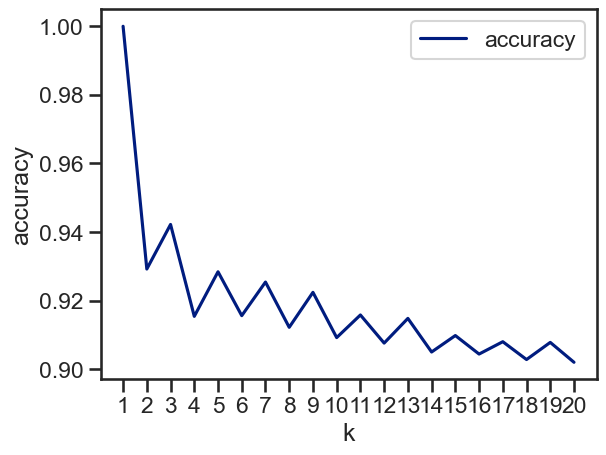

In [33]:
sns.set_context('talk')
sns.set_style('ticks')
sns.set_palette('dark')

ax = score_df.set_index('k').plot()

ax.set(xlabel='k', ylabel='accuracy')
ax.set_xticks(range(1, 21));